# NSA vs Dense vs Sliding Window — Needle-in-a-Haystack

Comparaison de **trois stratégies d'attention** sur une tâche NIAH ("Que fait Mathieu ?").

| Modèle | Mécanisme | Principe |
|--------|-----------|----------|
| **Dense** | Attention causale complète | Voit tout le passé — borne haute |
| **NSA** | Compressée + Sélective + Fenêtre | `output = g_cmp·o_cmp + g_slc·o_slc + g_swa·o_swa` |
| **SW** | Fenêtre glissante | Ne voit que les `WINDOW_SIZE` derniers tokens |

**NSA — trois composantes (papier [Yang et al. 2025]) :**
1. **Compressed** (`g_cmp`) : K,V mean-poolés par blocs → contexte global basse résolution
2. **Selected** (`g_slc`) : top-K blocs choisis par Q·k_cmp (stop-gradient sur les indices) → contexte pertinent
3. **Sliding Window** (`g_swa`) : fenêtre locale fixe → contexte récent

Les gates `g_cmp, g_slc, g_swa` sont des projections linéaires `D→H` apprises (+ sigmoid).


In [1]:
import os
if not os.path.exists("native-sparse-attention"):
    !git clone https://github.com/YentlCollin/native-sparse-attention.git
    %cd native-sparse-attention
    !pip install -e . -q
else:
    %cd native-sparse-attention


Cloning into 'native-sparse-attention'...
remote: Enumerating objects: 577, done.
remote: Counting objects: 100% (577/577), done.
remote: Compressing objects: 100% (305/305), done.
remote: Total 577 (delta 283), reused 546 (delta 252), pack-reused 0 (from 0)
Receiving objects: 100% (577/577), 1.21 MiB | 4.35 MiB/s, done.
Resolving deltas: 100% (283/283), done.
/content/native-sparse-attention
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for native_sparse_attention (pyproject.toml) ... done


In [2]:
import math, random, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Reproductibilité ────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

# ── Style matplotlib ────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 11, 'legend.framealpha': 0.9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
C_DENSE = '#2166ac'
C_NSA   = '#1a9641'
C_SW    = '#d73027'
COLORS  = {'Dense': C_DENSE, 'NSA': C_NSA, 'SW': C_SW}

# ── Tâche ────────────────────────────────────────────────────────────────
CTX_LENGTHS   = [128, 192, 256, 320]
NEEDLE_LEN    = 4
N_DISTRACTORS = 3
MAX_CTX       = max(CTX_LENGTHS)
MAX_X_LEN     = MAX_CTX + 6

# ── NSA ──────────────────────────────────────────────────────────────────
BLOCK_SIZE  = 32
TOP_K       = 3
WINDOW_SIZE = 32

# ── Modèle ───────────────────────────────────────────────────────────────
D = 128; N_HEADS = 4; D_HEAD = D // N_HEADS; N_LAYERS = 3; DROPOUT = 0.1

# ── Entraînement ─────────────────────────────────────────────────────────
BATCH_SIZE = 32
N_TRAIN    = 6400
N_EVAL     = 2400
N_EPOCHS   = 200
LR         = 3e-3
print(f'Budget : {N_EPOCHS} epochs x ~9s = ~{N_EPOCHS*9//60} min (NSA)')


Device : cuda
Budget : 200 epochs x ~9s = ~30 min (NSA)


In [3]:
ACTIONS      = ['nage','court','chante','lit','cuisine','peint',
                'joue','marche','dort','réfléchit','rit','jardine',
                'écrit','dessine','écoute','danse','mange','travaille',
                'voyage','médite']
FILL_VERBS   = ['dort','court','chante','lit','cuisine','peint',
                'joue','marche','réfléchit','rit','jardine']
FILL_WORDS   = [f'w{i}' for i in range(200)]
TODAY        = 'aujourdhui'
PAST_MARKERS = ['hier','avant','jadis','autrefois']
SEP_TOKEN    = '<sep>'; UNK_TOKEN = '<unk>'; PAD_TOKEN = '<pad>'

vocab = sorted(set(
    ACTIONS + FILL_VERBS + FILL_WORDS + [TODAY] + PAST_MARKERS +
    ['Mathieu','Que','fait','.','?', SEP_TOKEN, UNK_TOKEN, PAD_TOKEN]))
word2id    = {w: i for i, w in enumerate(vocab)}
id2word    = {i: w for w, i in word2id.items()}
VOCAB_SIZE = len(vocab)
PAD_ID     = word2id[PAD_TOKEN]
print(f'Vocabulaire : {VOCAB_SIZE} tokens  |  actions : {len(ACTIONS)}')


Vocabulaire : 233 tokens  |  actions : 20


In [4]:
def make_example(ctx_len, needle_start=None, n_dist=N_DISTRACTORS):
    action = random.choice(ACTIONS)
    ns = (random.randint(0, ctx_len - NEEDLE_LEN) if needle_start is None
          else max(0, min(int(needle_start), ctx_len - NEEDLE_LEN)))
    blocked = set(range(ns, ns + NEEDLE_LEN))
    dists, attempts = [], 0
    while len(dists) < n_dist and attempts < 300:
        attempts += 1; p = random.randint(0, ctx_len - 4)
        blk = set(range(p, p + 4))
        if not blocked & blk: dists.append(p); blocked |= blk
    tokens = [random.choice(FILL_WORDS) for _ in range(ctx_len)]
    tokens[ns:ns+NEEDLE_LEN] = [TODAY, 'Mathieu', action, '.']
    for dp in dists:
        tokens[dp:dp+4] = [random.choice(PAST_MARKERS), 'Mathieu',
                           random.choice(FILL_VERBS), '.']
    full = tokens + [SEP_TOKEN,'Que','fait','Mathieu',TODAY,'?', action]
    ids  = [word2id.get(w, word2id[UNK_TOKEN]) for w in full]
    x, y = ids[:-1], ids[-1]
    assert len(x) == ctx_len + 6
    pred_pos = ctx_len + 5
    assert x[pred_pos] == word2id['?']
    assert ids[ns] == word2id[TODAY]
    return x, y, pred_pos, ns, action


class NIAHDataset(Dataset):
    def __init__(self, n, ctx_lengths=CTX_LENGTHS):
        self.items = []
        for _ in range(n):
            ctx = random.choice(ctx_lengths)
            x, y, pp, *_ = make_example(ctx)
            self.items.append((x, y, pp))
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        x, y, pp = self.items[idx]
        x = x + [PAD_ID] * (MAX_X_LEN - len(x))
        return (torch.tensor(x,  dtype=torch.long),
                torch.tensor(y,  dtype=torch.long),
                torch.tensor(pp, dtype=torch.long))


random.seed(SEED); torch.manual_seed(SEED)
train_ds     = NIAHDataset(N_TRAIN)
eval_ds      = NIAHDataset(N_EVAL)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
eval_loader  = DataLoader(eval_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
print(f'Train: {N_TRAIN}  |  Eval: {N_EVAL}  |  Batches/epoch: {len(train_loader)}')


Train: 6400  |  Eval: 2400  |  Batches/epoch: 200


In [5]:
# ── NSA : implémentation batched (O(T²) mémoire, équivalent au papier) ──
#
# Production : le noyau Triton du repo opère sur les blocs sélectionnés
# directement (O(T·K·BS)) sans matérialiser la matrice T×T.
# Ici on la matérialise pour la lisibilité — résultats identiques.

def nsa_attention(Q, K, V, g_cmp, g_slc, g_swa,
                  block_size=BLOCK_SIZE, top_k=TOP_K, window_size=WINDOW_SIZE):
    """
    Q, K, V       : [B, H, T, DH]
    g_cmp/slc/swa : [B, H, T, 1]   gates (après sigmoid)
    Retourne      : [B, H, T, DH]
    """
    B, H, T, DH = Q.shape
    C   = math.ceil(T / block_size)
    sc  = DH ** -0.5
    dev = Q.device

    # ── 1. Compressed K,V ─────────────────────────────────────────────
    pad   = C * block_size - T
    k_cmp = F.pad(K,(0,0,0,pad)).view(B,H,C,block_size,DH).mean(3)  # [B,H,C,DH]
    v_cmp = F.pad(V,(0,0,0,pad)).view(B,H,C,block_size,DH).mean(3)

    t_idx = torch.arange(T, device=dev)
    c_idx = torch.arange(C, device=dev)
    causal = t_idx[:, None] >= t_idx[None, :]              # [T,T]

    # Masque causal compressé : bloc j visible si j <= t//BS
    cmp_ok = c_idx[None, :] <= t_idx[:, None] // block_size           # [T,C]
    s_cmp  = torch.matmul(Q * sc, k_cmp.transpose(-2,-1))             # [B,H,T,C]
    s_cmp  = s_cmp.masked_fill(~cmp_ok[None, None], float('-inf'))
    a_cmp  = s_cmp.softmax(-1)                                         # [B,H,T,C]
    o_cmp  = torch.matmul(a_cmp, v_cmp)                               # [B,H,T,DH]

    # ── 2. Sélection des blocs (stop-gradient, bloc courant forcé) ────
    cur = (t_idx[:,None]//block_size == c_idx[None,:]).float()         # [T,C]
    bi  = (a_cmp.detach() + cur[None,None]*1e6).topk(min(top_k,C),-1).indices
                                                                       # [B,H,T,Ks]
    # ── 3. Selected attention ─────────────────────────────────────────
    bs_rng   = torch.arange(block_size, device=dev)
    sel_mask = torch.zeros(B, H, T, T, dtype=torch.bool, device=dev)
    for k in range(bi.shape[-1]):
        tok = (bi[:,:,:,k].unsqueeze(-1)*block_size + bs_rng[None,None,None,:])
        sel_mask.scatter_(-1, tok.clamp(0,T-1), True)
    sel_mask &= causal[None, None]

    s_full = torch.matmul(Q, K.transpose(-2,-1)) * sc                 # [B,H,T,T]
    o_slc  = torch.matmul(s_full.masked_fill(~sel_mask,float('-inf')).softmax(-1), V)

    # ── 4. Sliding window ─────────────────────────────────────────────
    sw_ok = (t_idx[None,:] >= t_idx[:,None]-window_size+1) & causal   # [T,T]
    o_swa = torch.matmul(s_full.masked_fill(~sw_ok[None,None],float('-inf')).softmax(-1), V)

    # ── 5. Combinaison avec gates ─────────────────────────────────────
    return o_cmp*g_cmp + o_slc*g_slc + o_swa*g_swa


def sw_attention(Q, K, V, window_size=WINDOW_SIZE):
    B, H, T, DH = Q.shape
    t = torch.arange(T, device=Q.device)
    mask = (t[None,:] >= t[:,None]-window_size+1) & (t[:,None] >= t[None,:])
    s = torch.matmul(Q, K.transpose(-2,-1)) * (DH**-0.5)
    return torch.matmul(s.masked_fill(~mask[None,None],float('-inf')).softmax(-1), V)


print('Attention functions OK')


Attention functions OK


In [6]:
class SelfAttn(nn.Module):
    def __init__(self, D, H, mode):
        super().__init__()
        self.H, self.DH, self.mode = H, D//H, mode
        self.qkv  = nn.Linear(D, 3*D, bias=False)
        self.proj = nn.Linear(D,   D, bias=False)
        self.drop = DROPOUT
        if mode == 'nsa':
            self.g_cmp = nn.Linear(D, H, bias=False)
            self.g_slc = nn.Linear(D, H, bias=False)
            self.g_swa = nn.Linear(D, H, bias=False)

    def forward(self, x):
        B, T, _ = x.shape; H, DH = self.H, self.DH
        Q, K, V = self.qkv(x).view(B,T,3,H,DH).unbind(2)
        Q, K, V = Q.transpose(1,2), K.transpose(1,2), V.transpose(1,2)

        if self.mode == 'dense':
            dp  = self.drop if self.training else 0.
            out = F.scaled_dot_product_attention(Q,K,V,is_causal=True,dropout_p=dp)

        elif self.mode == 'nsa':
            def gate(lin): return torch.sigmoid(lin(x)).permute(0,2,1).unsqueeze(-1)
            out = nsa_attention(Q,K,V, gate(self.g_cmp), gate(self.g_slc), gate(self.g_swa))

        elif self.mode == 'sw':
            out = sw_attention(Q, K, V)

        return self.proj(out.transpose(1,2).contiguous().view(B,T,-1))


class Block(nn.Module):
    def __init__(self, D, H, mode):
        super().__init__()
        self.ln1  = nn.LayerNorm(D)
        self.attn = SelfAttn(D, H, mode)
        self.ln2  = nn.LayerNorm(D)
        self.ff   = nn.Sequential(nn.Linear(D,4*D), nn.GELU(),
                                  nn.Linear(4*D,D), nn.Dropout(DROPOUT))
    def forward(self, x):
        return x + self.ff(self.ln2(x + self.attn(self.ln1(x))))


class TinyGPT(nn.Module):
    def __init__(self, mode='dense'):
        super().__init__()
        self.tok_emb = nn.Embedding(VOCAB_SIZE, D)
        self.pos_emb = nn.Embedding(MAX_X_LEN, D)
        self.drop    = nn.Dropout(DROPOUT)
        self.blocks  = nn.ModuleList([Block(D, N_HEADS, mode) for _ in range(N_LAYERS)])
        self.ln_f    = nn.LayerNorm(D)
        self.head    = nn.Linear(D, VOCAB_SIZE, bias=False)
        self.head.weight = self.tok_emb.weight

    def forward(self, x):
        B, T = x.shape
        h = self.drop(self.tok_emb(x) + self.pos_emb(torch.arange(T, device=x.device)))
        for blk in self.blocks: h = blk(h)
        return self.head(self.ln_f(h))


def new_model(mode):
    torch.manual_seed(SEED)
    m = TinyGPT(mode).to(DEVICE)
    print(f'[{mode:6s}] {sum(p.numel() for p in m.parameters()):,} params')
    return m


In [7]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    tot_loss = tot_acc = n = 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, y, pp in loader:
            x, y, pp = x.to(DEVICE), y.to(DEVICE), pp.to(DEVICE)
            B      = x.size(0)
            pred   = model(x)[torch.arange(B,device=DEVICE), pp]
            loss   = F.cross_entropy(pred, y)
            if is_train:
                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            tot_loss += loss.item()*B
            tot_acc  += (pred.argmax(-1)==y).sum().item()
            n        += B
    return tot_loss/n, tot_acc/n


def train_model(mode, label):
    model = new_model(mode)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, N_EPOCHS, eta_min=LR*0.05)
    hist  = {k:[] for k in ('tr_loss','tr_acc','ev_loss','ev_acc')}
    sep   = '-'*54
    print(f'\n{sep}\n  {label}\n{sep}')
    print(f'{"Ep":>4} | {"TrLoss":>7} | {"TrAcc":>6} | {"EvLoss":>7} | {"EvAcc":>6} | {"t(s)":>5}')
    print(sep)
    log_every = max(1, N_EPOCHS//20)
    for ep in range(1, N_EPOCHS+1):
        t0      = time.time()
        tl, ta  = run_epoch(model, train_loader, opt)
        el, ea  = run_epoch(model, eval_loader)
        sched.step()
        for k,v in zip(('tr_loss','tr_acc','ev_loss','ev_acc'),(tl,ta,el,ea)):
            hist[k].append(v)
        if ep % log_every == 0 or ep == 1:
            print(f'{ep:4d} | {tl:7.4f} | {ta:6.3f} | {el:7.4f} | {ea:6.3f} | {time.time()-t0:5.1f}')
    print(f'\nFinal eval acc : {hist["ev_acc"][-1]:.3f}')
    return model, hist


In [8]:
model_dense, hist_dense = train_model('dense', 'Dense — attention causale complète')


[dense ] 665,088 params

------------------------------------------------------
  Dense — attention causale complète
------------------------------------------------------
  Ep |  TrLoss |  TrAcc |  EvLoss |  EvAcc |  t(s)
------------------------------------------------------
   1 |  5.8634 |  0.052 |  3.3749 |  0.049 |   4.3
  10 |  3.0766 |  0.053 |  3.0692 |  0.058 |   3.2
  20 |  3.0240 |  0.055 |  3.0383 |  0.049 |   3.2
  30 |  3.0009 |  0.063 |  3.0457 |  0.041 |   3.2
  40 |  2.9606 |  0.075 |  3.0618 |  0.049 |   3.3
  50 |  2.9214 |  0.091 |  3.0903 |  0.047 |   3.2
  60 |  2.8842 |  0.108 |  3.1480 |  0.045 |   3.2
  70 |  2.7928 |  0.137 |  3.2213 |  0.054 |   3.2
  80 |  2.7295 |  0.162 |  3.2959 |  0.047 |   3.2
  90 |  2.6463 |  0.187 |  3.4230 |  0.060 |   3.2
 100 |  2.3159 |  0.275 |  3.0864 |  0.139 |   3.2
 110 |  1.8470 |  0.416 |  2.5979 |  0.263 |   3.2
 120 |  1.2284 |  0.586 |  2.0215 |  0.418 |   3.2
 130 |  1.0174 |  0.660 |  1.8885 |  0.460 |   3.2
 140 |  

In [9]:
model_nsa,   hist_nsa   = train_model('nsa',   'NSA — compressée + sélective + fenêtre')


[nsa   ] 669,696 params

------------------------------------------------------
  NSA — compressée + sélective + fenêtre
------------------------------------------------------
  Ep |  TrLoss |  TrAcc |  EvLoss |  EvAcc |  t(s)
------------------------------------------------------
   1 |  6.0095 |  0.051 |  3.6680 |  0.050 |  12.6
  10 |  3.0650 |  0.054 |  3.0468 |  0.049 |  12.2
  20 |  2.7880 |  0.135 |  2.7116 |  0.165 |  12.2
  30 |  1.1271 |  0.640 |  0.8965 |  0.753 |  12.3
  40 |  0.7746 |  0.751 |  0.5859 |  0.813 |  12.3
  50 |  0.5056 |  0.837 |  0.4674 |  0.859 |  12.3
  60 |  0.2483 |  0.926 |  0.2422 |  0.930 |  12.2
  70 |  0.1497 |  0.954 |  0.1963 |  0.950 |  12.2
  80 |  0.0976 |  0.969 |  0.1561 |  0.964 |  12.2
  90 |  0.0631 |  0.980 |  0.1674 |  0.968 |  12.2
 100 |  0.0609 |  0.982 |  0.2025 |  0.970 |  12.2
 110 |  0.0335 |  0.990 |  0.1897 |  0.970 |  12.2
 120 |  0.0354 |  0.990 |  0.1802 |  0.973 |  12.2
 130 |  0.0112 |  0.996 |  0.2296 |  0.970 |  12.3
 140

In [10]:
model_sw,    hist_sw     = train_model('sw',    f'SW — fenêtre glissante {WINDOW_SIZE} tokens')


[sw    ] 665,088 params

------------------------------------------------------
  SW — fenêtre glissante 32 tokens
------------------------------------------------------
  Ep |  TrLoss |  TrAcc |  EvLoss |  EvAcc |  t(s)
------------------------------------------------------
   1 |  5.8855 |  0.048 |  3.4495 |  0.054 |   6.9
  10 |  3.0720 |  0.051 |  3.0694 |  0.055 |   6.9
  20 |  3.0152 |  0.061 |  3.0532 |  0.051 |   6.9
  30 |  2.9763 |  0.073 |  3.0694 |  0.042 |   6.8
  40 |  2.9349 |  0.092 |  3.0790 |  0.052 |   6.9
  50 |  2.8850 |  0.103 |  3.1314 |  0.048 |   6.9
  60 |  2.8292 |  0.123 |  3.1776 |  0.054 |   6.9
  70 |  2.7494 |  0.149 |  3.2998 |  0.049 |   6.9
  80 |  2.6438 |  0.180 |  3.4135 |  0.052 |   6.9
  90 |  2.5154 |  0.218 |  3.5816 |  0.049 |   6.9
 100 |  2.3710 |  0.260 |  3.8546 |  0.052 |   6.9
 110 |  2.1998 |  0.315 |  4.1242 |  0.050 |   6.9
 120 |  2.0169 |  0.370 |  4.3370 |  0.053 |   6.9
 130 |  1.8550 |  0.426 |  4.6817 |  0.056 |   6.8
 140 |  1.

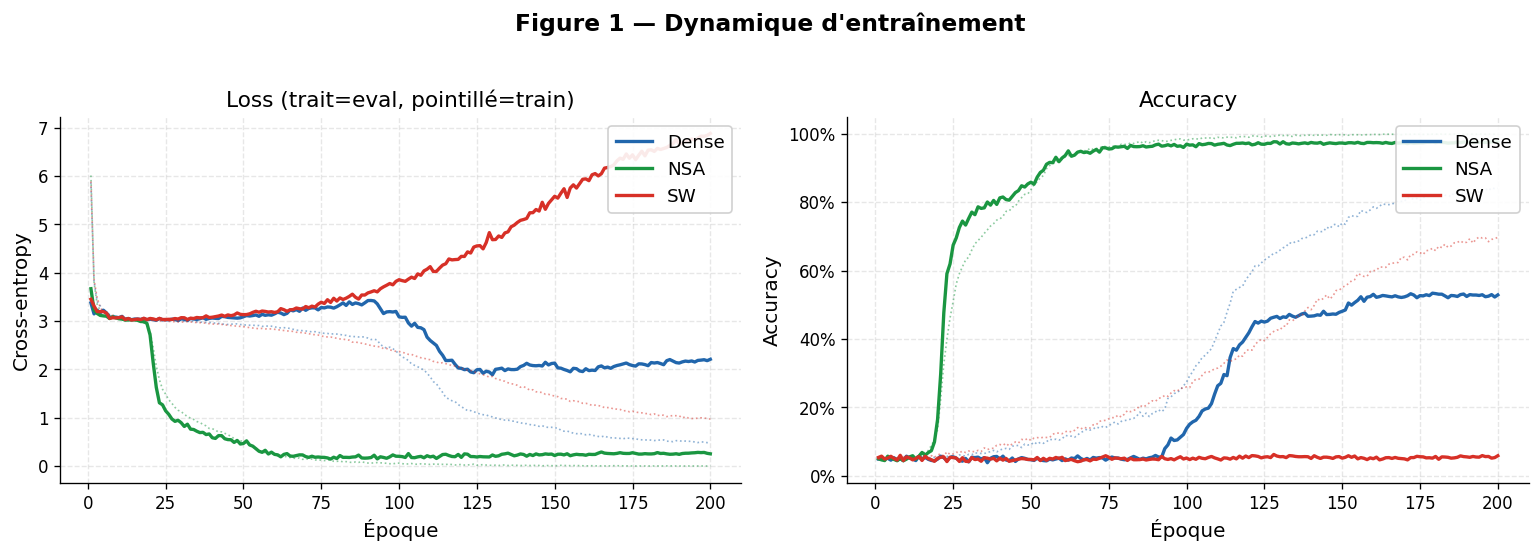

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = np.arange(1, N_EPOCHS+1)
RUNS   = [('Dense', hist_dense, C_DENSE),
          ('NSA',   hist_nsa,   C_NSA),
          ('SW',    hist_sw,    C_SW)]

for lbl, h, c in RUNS:
    axes[0].plot(epochs, h['ev_loss'], color=c, lw=2,   label=lbl)
    axes[0].plot(epochs, h['tr_loss'], color=c, lw=1, ls=':', alpha=0.5)
    axes[1].plot(epochs, h['ev_acc'],  color=c, lw=2,   label=lbl)
    axes[1].plot(epochs, h['tr_acc'],  color=c, lw=1, ls=':', alpha=0.5)

axes[0].set(title='Loss (trait=eval, pointillé=train)',
            xlabel='Époque', ylabel='Cross-entropy')
axes[1].set(title='Accuracy',
            xlabel='Époque', ylabel='Accuracy')
axes[1].set_ylim(-0.02, 1.05)
axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
for ax in axes: ax.legend(loc='upper right')
plt.suptitle('Figure 1 — Dynamique d\'entraînement', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/nsa_fig1_training.png')
plt.show()


In [12]:
def infer(model, x_ids, pred_pos):
    model.eval()
    x = torch.tensor([x_ids], dtype=torch.long, device=DEVICE)
    with torch.no_grad():
        return model(x)[0, pred_pos]


def compute_recall(model, ctx_len, n_samples=400, n_bins=10):
    """Recall vs position de l'aiguille dans le contexte."""
    model.eval()
    bins   = np.linspace(0, ctx_len - NEEDLE_LEN, n_bins+1)
    hits   = np.zeros(n_bins); counts = np.zeros(n_bins)
    for _ in range(n_samples):
        x, y, pp, ns, _ = make_example(ctx_len)
        x_p  = x + [PAD_ID]*(MAX_X_LEN - len(x))
        pred = infer(model, x_p, pp).argmax().item()
        b    = min(np.searchsorted(bins, ns, side='right')-1, n_bins-1)
        counts[b] += 1; hits[b] += int(pred == y)
    centers = (bins[:-1]+bins[1:])/2
    recalls = np.where(counts>0, hits/counts, np.nan)
    return centers, recalls, counts


print('Inference helpers OK')


Inference helpers OK


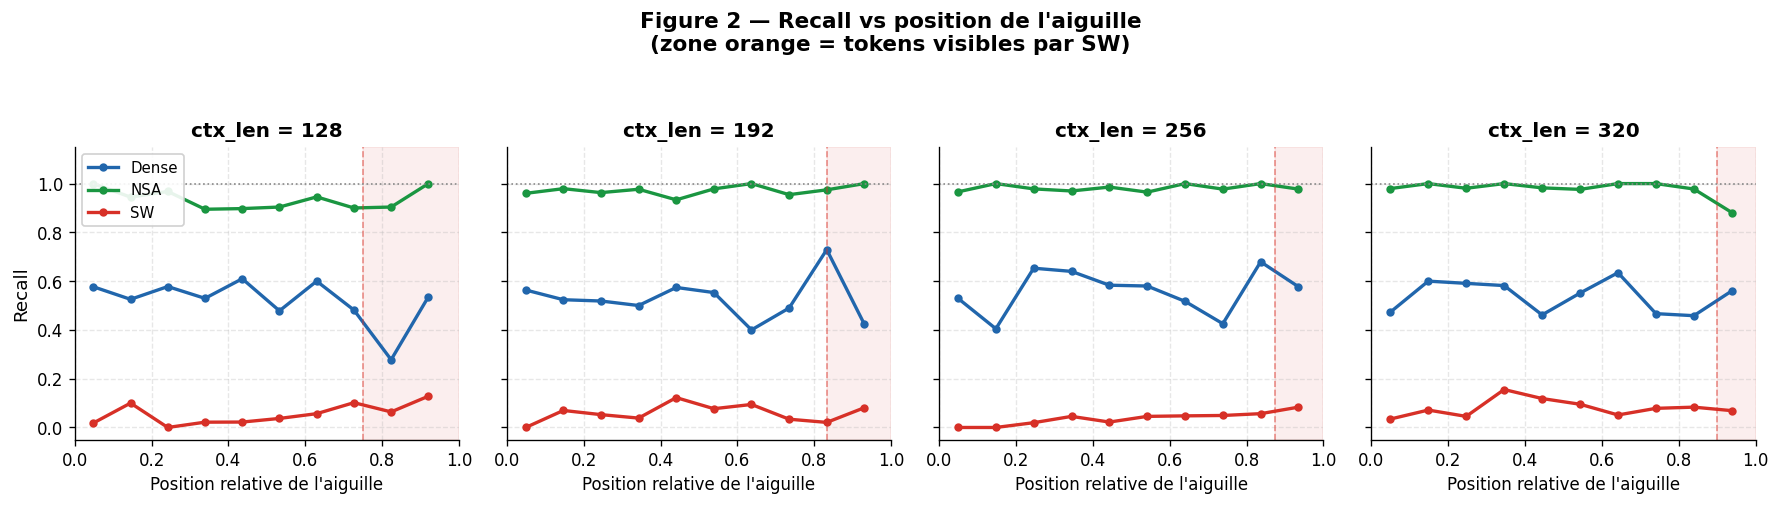

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
RUNS_M = [('Dense', model_dense, C_DENSE),
          ('NSA',   model_nsa,   C_NSA),
          ('SW',    model_sw,    C_SW)]

for col, ctx in enumerate(CTX_LENGTHS):
    ax = axes[col]
    recall_data = {}
    for lbl, model, color in RUNS_M:
        centers, recalls, _ = compute_recall(model, ctx, n_samples=500)
        rel_pos = centers / ctx
        ax.plot(rel_pos, recalls, '-o', color=color, lw=2, ms=4, label=lbl)
        recall_data[lbl] = recalls

    # Zone visible par SW
    sw_start = max(0, 1 - WINDOW_SIZE/ctx)
    ax.axvspan(sw_start, 1.0, alpha=0.08, color=C_SW, label='_SW window')
    ax.axvline(sw_start, color=C_SW, ls='--', lw=1, alpha=0.5)

    ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel('Position relative de l\'aiguille', fontsize=10)
    ax.set_title(f'ctx_len = {ctx}', fontsize=12, fontweight='bold')
    ax.axhline(1.0, color='#888', ls=':', lw=1)
    if col == 0:
        ax.set_ylabel('Recall', fontsize=11)
        ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Figure 2 — Recall vs position de l\'aiguille\n'
             '(zone orange = tokens visibles par SW)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('/tmp/nsa_fig2_recall_pos.png')
plt.show()


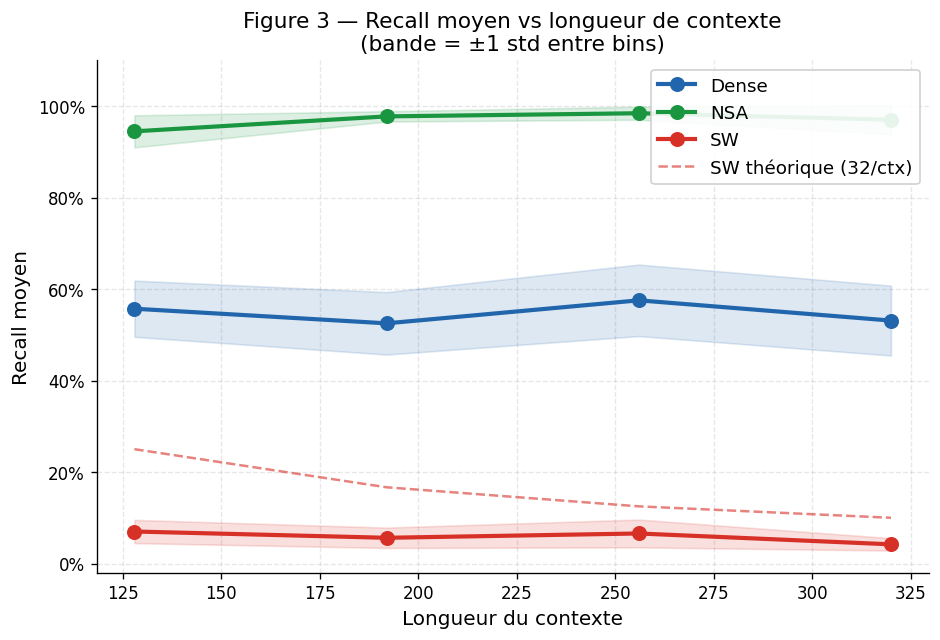

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for lbl, model, color in RUNS_M:
    means, stds = [], []
    for ctx in CTX_LENGTHS:
        _, recalls, _ = compute_recall(model, ctx, n_samples=600)
        m = np.nanmean(recalls); s = np.nanstd(recalls)
        means.append(m); stds.append(s)
    means, stds = np.array(means), np.array(stds)
    ax.plot(CTX_LENGTHS, means, 'o-', color=color, lw=2.5, ms=8, label=lbl, zorder=3)
    ax.fill_between(CTX_LENGTHS, means-stds, means+stds,
                    color=color, alpha=0.15, zorder=2)

# Courbe théorique SW (borne max = WINDOW_SIZE / ctx)
ctx_range = np.array(CTX_LENGTHS)
sw_theory = np.minimum(1.0, WINDOW_SIZE / ctx_range)
ax.plot(ctx_range, sw_theory, '--', color=C_SW, lw=1.5, alpha=0.6,
        label=f'SW théorique ({WINDOW_SIZE}/ctx)')

ax.set(title='Figure 3 — Recall moyen vs longueur de contexte\n'
             '(bande = ±1 std entre bins)',
       xlabel='Longueur du contexte', ylabel='Recall moyen')
ax.set_ylim(-0.02, 1.10)
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/nsa_fig3_recall_ctx.png')
plt.show()


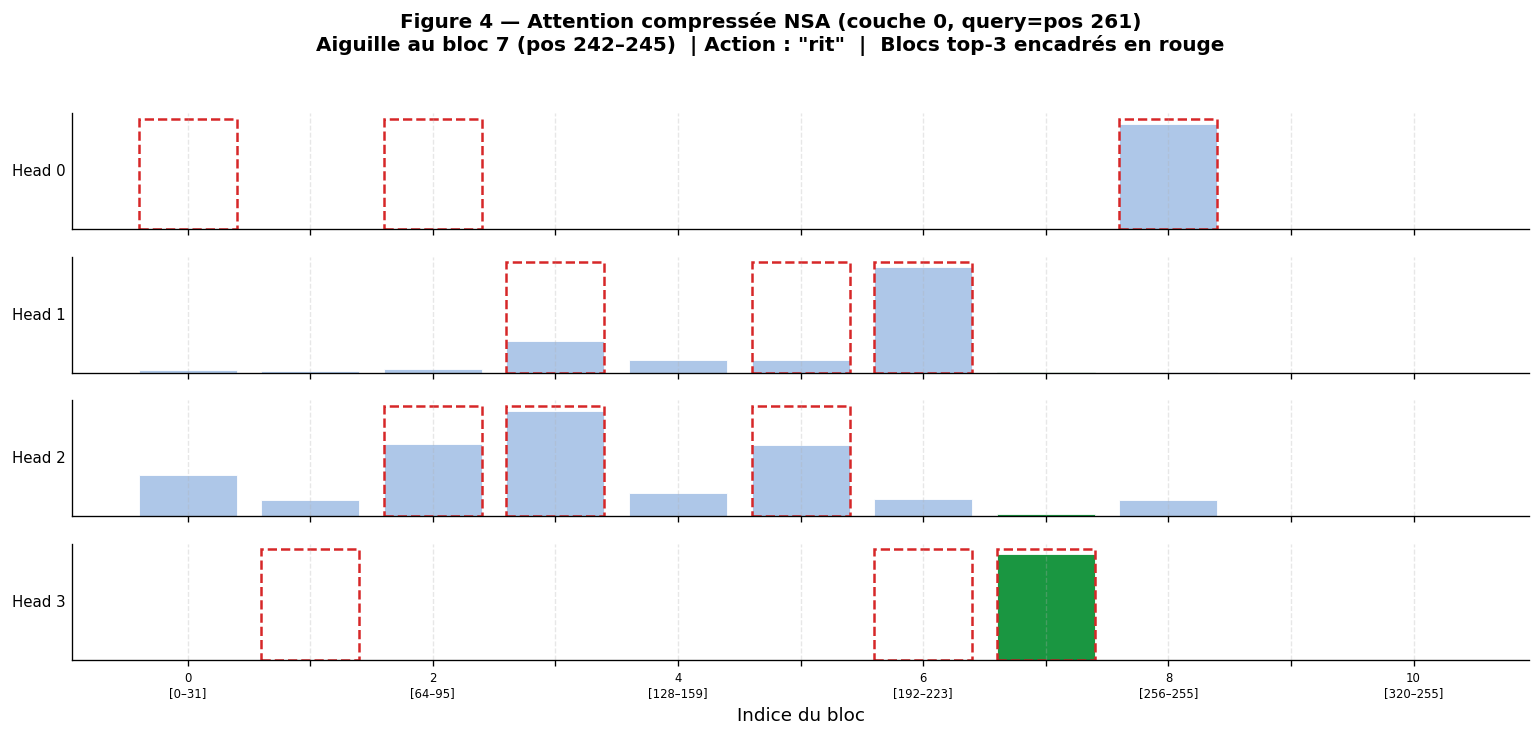

In [15]:
# Visualise les scores d'attention compressée de NSA pour un exemple test
# → montre quels blocs le modèle apprend à sélectionner

def get_nsa_block_scores(model, ctx_len=256, needle_start=None):
    """Retourne a_cmp[query, head, block] pour la couche 0."""
    x, y, pp, ns, action = make_example(ctx_len, needle_start=needle_start)
    x_p = x + [PAD_ID]*(MAX_X_LEN - len(x))
    x_t = torch.tensor([x_p], dtype=torch.long, device=DEVICE)

    model.eval()
    with torch.no_grad():
        B, T = x_t.shape
        h = model.drop(model.tok_emb(x_t) + model.pos_emb(torch.arange(T, device=DEVICE)))
        # Couche 0 : extraire Q, K et calculer a_cmp
        blk   = model.blocks[0]
        x_ln  = blk.ln1(h)
        QKV   = blk.attn.qkv(x_ln).view(B, T, 3, N_HEADS, D_HEAD)
        Q, K  = QKV[:,:,0].transpose(1,2), QKV[:,:,1].transpose(1,2)  # [1,H,T,DH]
        C     = math.ceil(T / BLOCK_SIZE)
        k_cmp = F.pad(K,(0,0,0,C*BLOCK_SIZE-T)).view(1,N_HEADS,C,BLOCK_SIZE,D_HEAD).mean(3)
        t_idx = torch.arange(T, device=DEVICE)
        c_idx = torch.arange(C, device=DEVICE)
        cmp_ok = c_idx[None,:] <= t_idx[:,None]//BLOCK_SIZE
        s_cmp  = torch.matmul(Q*(D_HEAD**-0.5), k_cmp.transpose(-2,-1))
        s_cmp  = s_cmp.masked_fill(~cmp_ok[None,None], float('-inf'))
        a_cmp  = s_cmp.softmax(-1)   # [1,H,T,C]

    # Score de chaque bloc pour la position query (pp)
    scores = a_cmp[0, :, pp, :C].cpu().numpy()  # [H, C]
    return scores, ns, pp, action, C, ctx_len


random.seed(7)
scores, ns, pp, action, C, ctx_len = get_nsa_block_scores(model_nsa, ctx_len=256)

needle_block = ns // BLOCK_SIZE
fig, axes = plt.subplots(N_HEADS, 1, figsize=(13, 6), sharex=True)

for h in range(N_HEADS):
    ax = axes[h]
    bar_colors = ['#aec7e8'] * C
    bar_colors[needle_block] = C_NSA
    # Distracteurs : blocs contenant 'hier/avant...'
    ax.bar(range(C), scores[h], color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_ylabel(f'Head {h}', rotation=0, ha='right', va='center', fontsize=9)
    ax.set_yticks([])
    # Marque top-K sélectionnés
    topk_idx = np.argsort(scores[h])[-TOP_K:]
    for ki in topk_idx:
        ax.add_patch(plt.Rectangle((ki-0.4, 0), 0.8, scores[h].max()*1.05,
                                   fill=False, edgecolor='#d62728', lw=1.5, ls='--'))

axes[-1].set_xlabel('Indice du bloc', fontsize=11)
axes[-1].set_xticks(range(C))
axes[-1].set_xticklabels(
    [f'{i}\n[{i*BLOCK_SIZE}–{min((i+1)*BLOCK_SIZE,ctx_len)-1}]'
     if i % 2 == 0 else '' for i in range(C)], fontsize=7)

fig.suptitle(
    f'Figure 4 — Attention compressée NSA (couche 0, query=pos {pp})\n'
    f'Aiguille au bloc {needle_block} (pos {ns}–{ns+3})  '
    f'| Action : "{action}"  |  Blocs top-{TOP_K} encadrés en rouge',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/tmp/nsa_fig4_blocks.png')
plt.show()


In [16]:
print(f'\n{"="*65}')
print(f'{"Modèle":<10} | ' + ' | '.join(f'ctx={c}' for c in CTX_LENGTHS) + ' | Moy.')
print(f'{"-"*65}')
for lbl, model, _ in RUNS_M:
    vals = [np.nanmean(compute_recall(model, ctx, n_samples=600)[1]) for ctx in CTX_LENGTHS]
    print(f'{lbl:<10} | ' + ' | '.join(f'{v:.3f} ' for v in vals) + f'| {np.mean(vals):.3f}')
print(f'{"="*65}')
print(f'Architecture : D={D}, H={N_HEADS}, L={N_LAYERS}')
print(f'NSA params   : BS={BLOCK_SIZE}, K={TOP_K}, W={WINDOW_SIZE}')
print(f'Epochs       : {N_EPOCHS}  |  N_train={N_TRAIN}  |  N_eval={N_EVAL}')



Modèle     | ctx=128 | ctx=192 | ctx=256 | ctx=320 | Moy.
-----------------------------------------------------------------
Dense      | 0.594  | 0.539  | 0.536  | 0.535 | 0.551
NSA        | 0.931  | 0.963  | 0.979  | 0.981 | 0.964
SW         | 0.049  | 0.049  | 0.058  | 0.051 | 0.052
Architecture : D=128, H=4, L=3
NSA params   : BS=32, K=3, W=32
Epochs       : 200  |  N_train=6400  |  N_eval=2400
